In [1]:
import pandas as pd
import numpy as np
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_score
from sklearn import metrics
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '../..')

from rb_clf_V2.scripts.utils import plot_config
from rb_clf_V2.scripts.train_RBclf import load_single, get_akb_labels
import time

plot_config()

In [2]:
    akb = get_akb_labels(f'../data/akb.ztf.snad.space.json')
    with open(f'../../dr23-features/feature_snad_clf_r_100.name') as f:
        names = f.read().split()[:-1]


    oids, features = load_single(f'../../dr23-features/sid_snad_clf_r_100.dat',
                                 f'../../dr23-features/feature_snad_clf_r_100.dat')

    crossmatch = np.load(f'../data/crossmatch.npy')       

    akb_features = features[crossmatch][:, :-1]
    akb_labels = np.array([akb[oid] for oid in oids[crossmatch]]).reshape((-1,1))
    data = pd.DataFrame(data=np.hstack([akb_features, akb_labels]), columns=names+['label'])


In [3]:
    rs = 42
    print('Training model...')
    t = time.monotonic()
    model = RandomForestClassifier(max_depth=18, n_estimators=831, random_state=rs)
    score_types = ('accuracy', 'roc_auc', 'f1')

    result = cross_validate(model, data[names], data['label'],
                        cv=KFold(shuffle=True, random_state=rs),
                        scoring=score_types,
                        return_estimator=True,
                        return_train_score=True,
                       )

    print('Scores for Random Forest Classifier:')
    for score in score_types:
        mean = np.mean(result[f'test_{score}'])
        std = np.std(result[f'test_{score}'])
        print(f'{score} = {mean:.3f} +- {std:.3f}')
    t = (time.monotonic() - t) / 60
    print(f'RF trained (with cross-validation) in {t:.0f} m')
 

Training model...
Scores for Random Forest Classifier:
accuracy = 0.903 +- 0.012
roc_auc = 0.965 +- 0.005
f1 = 0.890 +- 0.016
RF trained (with cross-validation) in 2 m


/tmp/ipykernel_1496/620907260.py:22: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


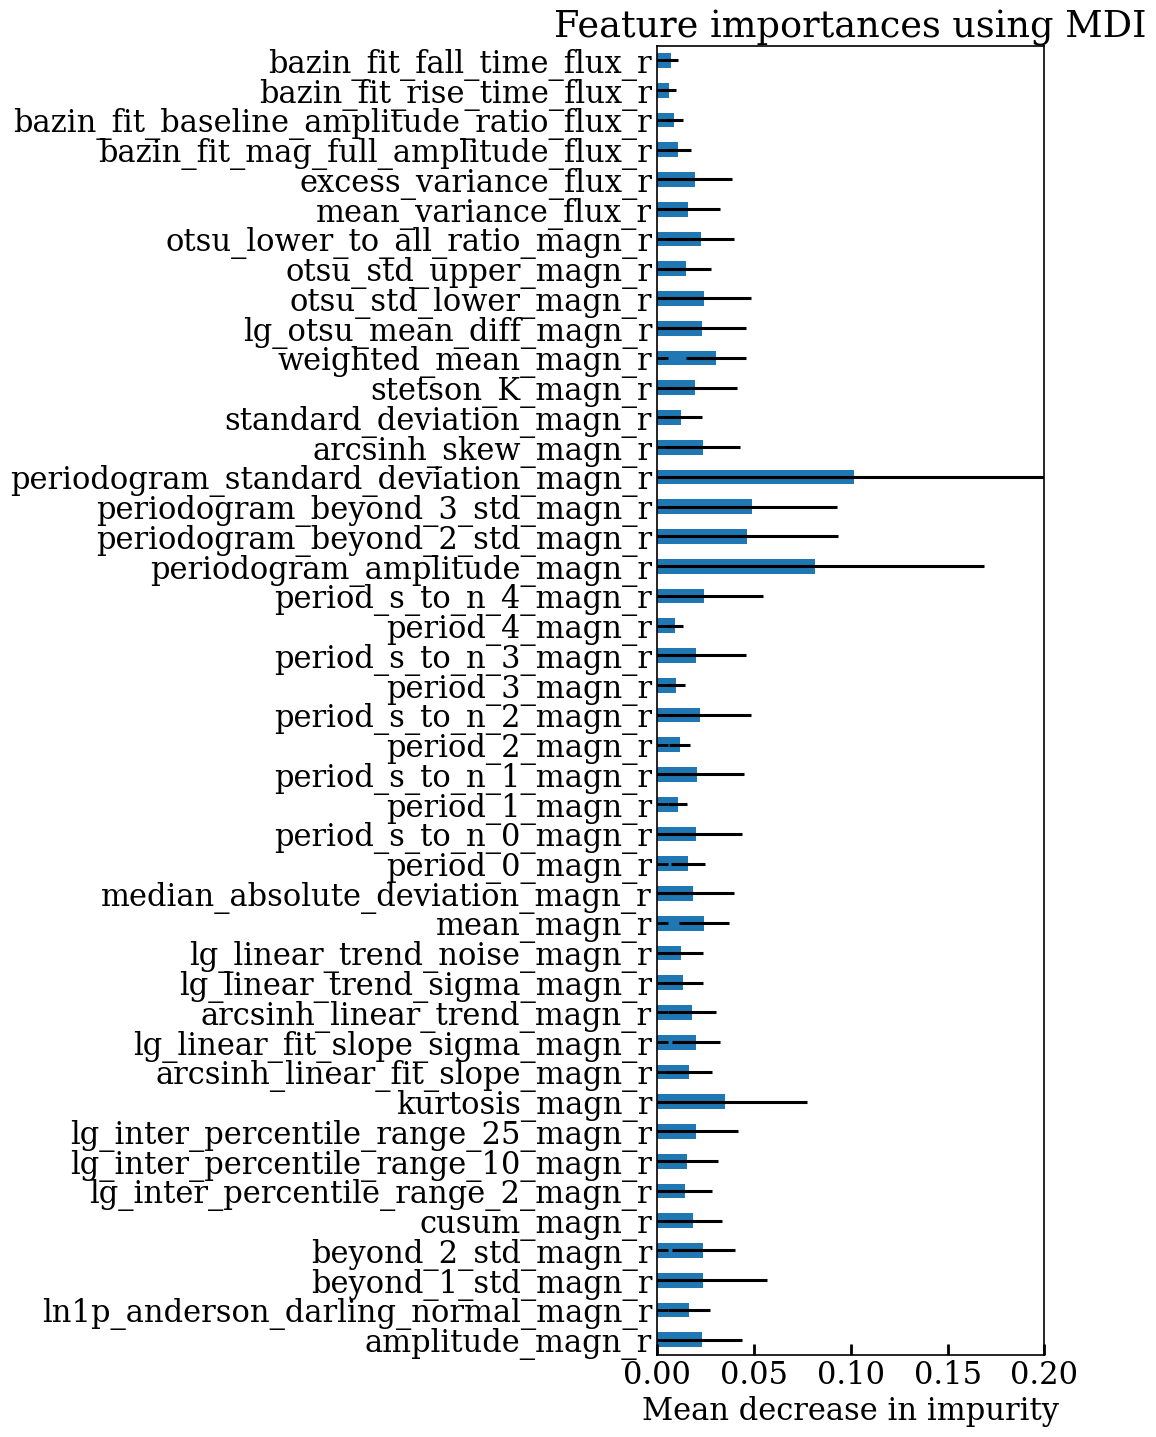

In [15]:
clf = result['estimator'][0]

importances = clf.feature_importances_
std = np.std([tree.feature_importances_ for tree in clf.estimators_], axis=0)

forest_importances = pd.Series(importances, index=names)

# fig, ax = plt.subplots(figsize=(15,5))
# forest_importances.plot.bar(yerr=std, ax=ax)
# ax.set_title("Feature importances using MDI")
# ax.set_ylabel("Mean decrease in impurity")
# plt.ylim(0, 0.2)
#fig.tight_layout()


fig, ax = plt.subplots(figsize=(5,17))
# Используем barh вместо bar для горизонтальных столбцов
forest_importances.plot.barh(xerr=std, ax=ax)  # xerr вместо yerr для горизонтального графика
ax.set_title("Feature importances using MDI")
ax.set_xlabel("Mean decrease in impurity")  # Изменили ylabel на xlabel
plt.xlim(0, 0.2)  # Изменили ylim на xlim
fig.tight_layout()

#plt.savefig('feature_imp.png', bbox_inches='tight')